# Linopy Übung 2

### a. Dynamischer Stromtarif mit Heimspeicher

Da seit 2025 dynamische Stromtarife verpflichtend angeboten werden müssen, überlegen Sie ihren Tarif zu einen solchen zu wechseln. Um Ihren Verbrauch zu flexibilisieren wollen Sie sich einen Lithium-Ionen-Heimspeicher zulegen. Ihnen liegen die Strompreise für 2024 stündlich aufgeschlüsselt, sowie der Stromverbrauch ihres Eigenheims vor. Bestimmen Sie die ökonomisch optimale Größe des Heimspeichers.

Die Kosten für den Heimspeicher können mit 750 €/kWh angenommen werden. Die Lebenszeit beträgt 20 Jahre, der Zinssatz kann mit 2% angenommen werden. Die _round trip_ Effizienz beträgt 95%. Standverluste können vernachlässigt werden.

Importieren Sie zunächst die notwendigen Bibliotheken

In [368]:
import linopy as lp
import pandas as pd

Lesen Sie die Strompreise sowie Netzlast aus der csv-Datei als Pandas-Dataframe ein. Nutzen Sie:
```python
dataframe_name = pd.read_csv("dateiname")
```

In [369]:
df_data = pd.read_csv('data_Linopy_2.csv')

Definieren Sie einen passenden Index. Statt alle Perioden in einzeln zu definieren, können sie range(start, stop) verwenden. Der Befehl erzeugt eine Folge ganzer Zahlen von start bis stop-1.

In [370]:
t = pd.Index(range(0,8784), name="snapshots")

Berechnen Sie die Stromkosten ohne Heimspeicher

In [371]:
strompreis = pd.Series(df_data['Strompreis [Euro/kWh]'], index=t, name="Strompreis in €/kWh")
last = pd.Series(df_data['Netzlast [kW]'], index=t, name="Last in kW")

ref_kosten = sum(strompreis * last)
print("Stromkosten ohne Heimspeicher:", round(ref_kosten, 2), '€')

Stromkosten ohne Heimspeicher: 1243.5 €


Definieren Sie die gegebenen Parameter. 

In [372]:
zinssatz = 0.02
batterie_lebensdauer = 20
batterie_kosten = 750*((1+zinssatz)**batterie_lebensdauer)*zinssatz/((1+zinssatz)**batterie_lebensdauer-1)
batterie_wirkungsgrad = 0.95

Bauen Sie ein Modell auf, welches die Problemstellung abbildet und geben Sie das fertige Modell aus.

In [373]:
model = lp.Model()

# Variablen des Modells
batterie_kapazitaet = model.add_variables(lower=0, name="Batteriespeichergröße in kWh")
batterie_fuellstand = model.add_variables(lower=0, coords=[t], name="Batteriebeladung in kWh")
netzbezug = model.add_variables(lower=0, coords=[t], name="Netzbezug in kW")
batterie_ladeleistung = model.add_variables(lower=0, coords=[t], name="Ladeleistung der Batterie in kW")
batterie_entladeleistung = model.add_variables(lower=0, coords=[t], name="Entladeleistung der Batterie in kW")

# Zielfunktion des Modells
model.add_objective(expr=(netzbezug * strompreis).sum() + batterie_kapazitaet * batterie_kosten, sense="min")

# Nebenbedingungen des Modells
model.add_constraints(lhs=netzbezug - batterie_ladeleistung + batterie_entladeleistung, sign="==", rhs=last, name="Leistungsbilanz")
model.add_constraints(lhs=batterie_fuellstand, sign="<=", rhs=batterie_kapazitaet, name="Begrenzung Füllstand")
model.add_constraints(lhs=batterie_fuellstand[0], sign="==", rhs=0, name="Füllstand Beginn")
model.add_constraints(lhs= batterie_fuellstand[1:], sign="==", rhs=batterie_fuellstand[:-1] + batterie_ladeleistung[1:] * batterie_wirkungsgrad ** 0.5 - batterie_entladeleistung[1:] / batterie_wirkungsgrad ** 0.5, name="Füllstand")
model.add_constraints(lhs= batterie_entladeleistung, sign="<=", rhs= batterie_kapazitaet, name="Begrenzung Entladeleistung")
model.add_constraints(lhs= batterie_ladeleistung, sign="<=", rhs= batterie_kapazitaet, name="Begrenzung Ladeleistung")


# Fertiges Modell
print(model)

Linopy LP model

Variables:
----------
 * Batteriespeichergröße in kWh
 * Batteriebeladung in kWh (snapshots)
 * Netzbezug in kW (snapshots)
 * Ladeleistung der Batterie in kW (snapshots)
 * Entladeleistung der Batterie in kW (snapshots)

Constraints:
------------
 * Leistungsbilanz (snapshots)
 * Begrenzung Füllstand (snapshots)
 * Füllstand Beginn (snapshots)
 * Füllstand (snapshots)
 * Begrenzung Entladeleistung (snapshots)
 * Begrenzung Ladeleistung (snapshots)

Status:
-------
initialized


Lösen Sie das Modell

In [374]:
model.solve(solver_name="gurobi")

Writing continuous variables.: 100%|██████████| 5/5 [00:00<00:00, 133.29it/s]

Set parameter Username


Set parameter LicenseID to value 2795258
Academic license - for non-commercial use only - expires 2027-03-20
Read LP format model from file C:\Users\samik\AppData\Local\Temp\linopy-problem-_0u9sdh8.lp
Reading time = 0.22 seconds
obj: 43920 rows, 35137 columns, 114189 nonzeros
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: 13th Gen Intel(R) Core(TM) i7-13705H, instruction set [SSE2|AVX|AVX2]
Thread count: 14 physical cores, 20 logical processors, using up to 20 threads

Optimize a model with 43920 rows, 35137 columns and 114189 nonzeros (Min)
Model fingerprint: 0x231cdbce
Model has 8785 linear objective coefficients
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [5e-02, 5e+01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e-01, 2e+00]

Presolve removed 5 rows and 3 columns
Presolve time: 0.21s
Presolved: 17568 rows, 43915 columns, 122957 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex,

('ok', 'optimal')

Geben Sie sich die Größe des Batteriespeichers, die Batteriekosten und die jährlichen Gesamtkosten (Zielfunktion) aus.

In [375]:
print('Batterie-Kapazität',round(batterie_kapazitaet.solution.item(),2),"kWh" )
batteriekosten = batterie_kapazitaet.solution.item() * batterie_kosten * batterie_lebensdauer
print('Batteriespeicher-Gesamtkosten:', round(batteriekosten,2), "€")
print('Jährliche Kosten', round(model.objective.value, 2), '€')

Batterie-Kapazität 0.59 kWh
Batteriespeicher-Gesamtkosten: 543.96 €
Jährliche Kosten 1240.04 €


Wie groß fällt die jährliche Ersparnis aus? Wie lang ist die Amortisationszeit des Batteriespeichers?

In [376]:
ersparnis_betriebskosten = ref_kosten - model.objective.value + batterie_kapazitaet.solution.item() * batterie_kosten
print('Ersparnis:', round (ersparnis_betriebskosten, 2), '€/a')
print('Amortisationszeit:', round(batteriekosten/ersparnis_betriebskosten, 2), 'Jahre')

Ersparnis: 30.66 €/a
Amortisationszeit: 17.74 Jahre


Erstellen Sie ein Ergebnis-Dataframe bestehend aus der Beladung und Leistung der Batterie, sowie dem Netzbezug.

In [377]:
# Erstelle ein Pandas DataFrame
ergebnisse_a = pd.DataFrame(index=t)

# Extraktion aus Solution xArrays
ergebnisse_a["Batterie Füllstand"]= batterie_fuellstand.solution
ergebnisse_a["Batterie Ladeleistung"] = batterie_ladeleistung.solution
ergebnisse_a["Batterie Entladeleistung"] = batterie_entladeleistung.solution
ergebnisse_a["Netzbezug"] = netzbezug.solution

Diskutieren Sie das Verhalten des Speichers in Abhängigkeit des Strompreises mithilfe einer Grafik.

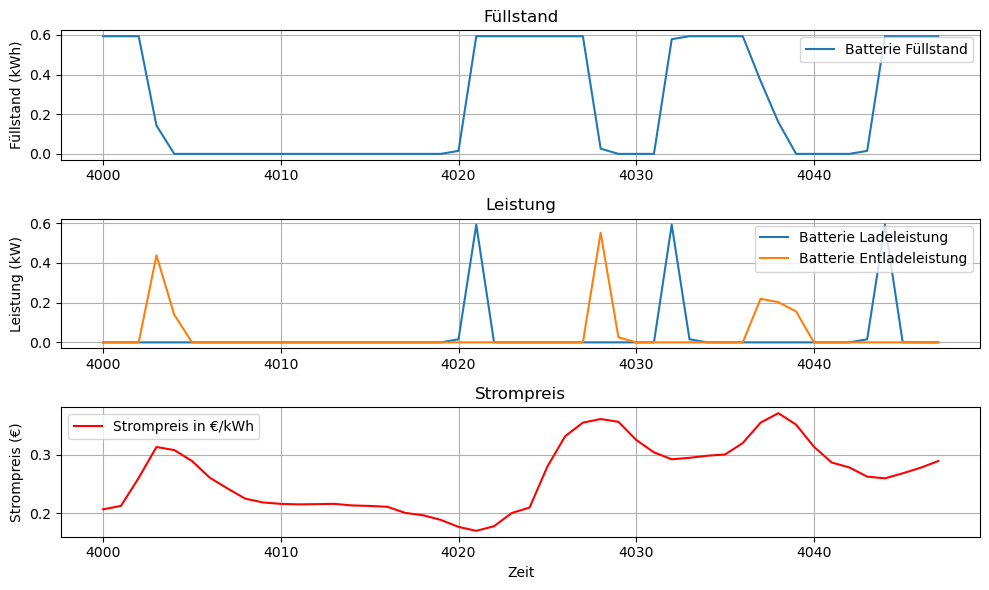

In [378]:
import matplotlib.pyplot as plt 

fig, axes = plt.subplots(nrows=3, figsize=(10, 6))

# Erstes Diagramm (Füllstand)
ergebnisse_a["Batterie Füllstand"][4000:4048].plot(ax=axes[0], legend=True, title="Füllstand")
axes[0].set_xlabel(None)
axes[0].set_ylabel("Füllstand (kWh)")
axes[0].grid(True)

# Zweites Diagramm (Leistungen)
ergebnisse_a["Batterie Ladeleistung"][4000:4048].plot(ax=axes[1], legend=True, title="Leistung")
ergebnisse_a["Batterie Entladeleistung"][4000:4048].plot(ax=axes[1], legend=True)
axes[1].set_xlabel(None)
axes[1].set_ylabel("Leistung (kW)")
axes[1].grid(True)

# Drittes Diagramm (Strompreis)
strompreis[4000:4048].plot(ax=axes[2], color="r", legend=True, title="Strompreis")
axes[2].set_ylabel("Strompreis (€)")
axes[2].grid(True)

# Gemeinsame X-Achse benennen
axes[2].set_xlabel("Zeit")

plt.tight_layout() 
plt.show()

### b. Dynamischer Stromtarif mit Heimspeicher und PV-Anlage

Nun soll ein zweites Szenario untersucht werden, in dem auf dem Dach des Eigenheims eine bestehende PV-Anlage mit einer Nennleistung von 5 kW installiert ist. Die Einspeisevergütung der Anlage liegt bei 8 ct/kWh. Die Kosten für den Heimspeicher bleiben gleich. 


Lesen Sie die PV-Erzeugung aus der csv-Datei als Pandas-Dataframe ein.

In [379]:
pv_erzeugung = pd.Series(df_data['PV Erzeugung [kW]'], index=t, name="PV-Erzeugung in kW")

Nehmen Sie nun die notwendigen Eränzungen und Änderungen am Modell vor.

In [380]:
# Neuer Parameter 
einspeiseverguetung = 0.08  # €/kWh

# Neue Variable des Modells
netzeinspeisung = model.add_variables(lower=0, coords=[t], name="Netzeinspeisung in kW")

# Neue/aktualisierte Nebenbedingungen des Modells
model.add_constraints(netzeinspeisung, "<=", pv_erzeugung, name="Maximale Einspeisung")
model.constraints["Leistungsbilanz"].lhs = netzbezug - netzeinspeisung + pv_erzeugung - batterie_ladeleistung + batterie_entladeleistung 

# Aktualisierte Zielfunktion des Modells
model.objective = (netzbezug * strompreis - netzeinspeisung * einspeiseverguetung).sum() + batterie_kapazitaet * batterie_kosten

# Fertiges Modell
print(model)

Linopy LP model

Variables:
----------
 * Batteriespeichergröße in kWh
 * Batteriebeladung in kWh (snapshots)
 * Netzbezug in kW (snapshots)
 * Ladeleistung der Batterie in kW (snapshots)
 * Entladeleistung der Batterie in kW (snapshots)
 * Netzeinspeisung in kW (snapshots)

Constraints:
------------
 * Leistungsbilanz (snapshots)
 * Begrenzung Füllstand (snapshots)
 * Füllstand Beginn (snapshots)
 * Füllstand (snapshots)
 * Begrenzung Entladeleistung (snapshots)
 * Begrenzung Ladeleistung (snapshots)
 * Maximale Einspeisung (snapshots)

Status:
-------
ok


Lösen Sie das angepasste Modell.

In [381]:
model.solve(solver_name="gurobi")

Writing continuous variables.: 100%|██████████| 6/6 [00:00<00:00, 226.59it/s]

Set parameter Username
Set parameter LicenseID to value 2795258
Academic license - for non-commercial use only - expires 2027-03-20


Read LP format model from file C:\Users\samik\AppData\Local\Temp\linopy-problem-d_dp9euk.lp
Reading time = 0.18 seconds
obj: 52704 rows, 43921 columns, 131757 nonzeros
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: 13th Gen Intel(R) Core(TM) i7-13705H, instruction set [SSE2|AVX|AVX2]
Thread count: 14 physical cores, 20 logical processors, using up to 20 threads

Optimize a model with 52704 rows, 43921 columns and 131757 nonzeros (Min)
Model fingerprint: 0xf8f6beb5
Model has 17569 linear objective coefficients
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [5e-02, 5e+01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [3e-04, 4e+00]

Presolve removed 8789 rows and 4435 columns
Presolve time: 0.27s
Presolved: 21920 rows, 48267 columns, 131661 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time: 0.01s

Barrier statistics:
 AA' NZ     : 5.69

('ok', 'optimal')

Geben Sie sich die neuen Werte der Größe des Batteriespeichers, der Batteriekosten und der jährlichen Gesamtkosten (Zielfunktion) aus.

In [382]:
print('Batterie-Kapazität',round(batterie_kapazitaet.solution.item(),2),"kWh" )
batteriekosten = batterie_kapazitaet.solution.item() * batterie_kosten * batterie_lebensdauer
print('Batteriespeicher-Gesamtkosten:', round(batteriekosten,2), "€")
print('Jährliche Kosten', round(model.objective.value, 2), '€')

Batterie-Kapazität 4.17 kWh
Batteriespeicher-Gesamtkosten: 3826.34 €
Jährliche Kosten 315.39 €


Wie groß fällt nun die jährliche Ersparnis aus und wie lang ist die neue Armotisationszeit?

In [383]:
# Neue Referenzkosten: PV-Anlage wird für Eigenverbrauch genutzt, der Rest wird eingespeist.
nettolast = last - pv_erzeugung
ref_kosten_pv = (nettolast.where(cond=nettolast > 0, other = 0) * strompreis + nettolast.where(cond=nettolast < 0, other = 0) * einspeiseverguetung).sum()

ersparnis_betriebskosten = ref_kosten_pv - model.objective.value + batterie_kapazitaet.solution.item() * batterie_kosten
print('Ersparnis:', round (ersparnis_betriebskosten, 2), '€/a')
print('Amortisationszeit:', round(batteriekosten/ersparnis_betriebskosten, 2), 'Jahre')

Ersparnis: 317.37 €/a
Amortisationszeit: 12.06 Jahre


Erstellen Sie ein neues Ergebnis-Dataframe für die neuen Werte.

In [384]:
# Erstelle ein Pandas DataFrame
ergebnisse_b = pd.DataFrame(index=t)

# Extraktion aus Solution xArrays
ergebnisse_b["Batterie Füllstand"]= batterie_fuellstand.solution
ergebnisse_b["Batterie Ladeleistung"] = batterie_ladeleistung.solution
ergebnisse_b["Batterie Entladeleistung"] = batterie_entladeleistung.solution
ergebnisse_b["Netzbezug"] = netzbezug.solution

Diskutieren Sie das neue Speicherverhalten, welches nun abhängig von PV-Erzeugung und Strompreis ist, mithilfe einer Grafik.

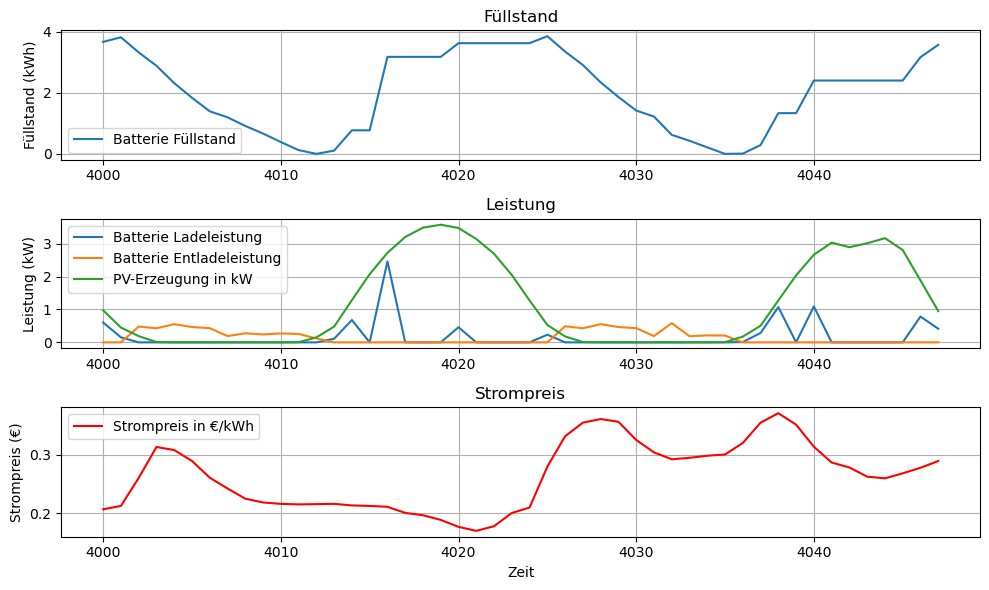

In [385]:
fig, axes = plt.subplots(nrows=3, figsize=(10, 6))

# Erstes Diagramm (Füllstand)
ergebnisse_b["Batterie Füllstand"][4000:4048].plot(ax=axes[0], legend=True, title="Füllstand")
axes[0].set_xlabel(None)
axes[0].set_ylabel("Füllstand (kWh)")
axes[0].grid(True)

# Zweites Diagramm (Leistungen)
ergebnisse_b["Batterie Ladeleistung"][4000:4048].plot(ax=axes[1], legend=True, title="Leistung")
ergebnisse_b["Batterie Entladeleistung"][4000:4048].plot(ax=axes[1], legend=True)
pv_erzeugung[4000:4048].plot(ax=axes[1], legend=True)
axes[1].set_xlabel(None)
axes[1].set_ylabel("Leistung (kW)")
axes[1].grid(True)

# Drittes Diagramm (Strompreis)
strompreis[4000:4048].plot(ax=axes[2], color="r", legend=True, title="Strompreis")
axes[2].set_ylabel("Strompreis (€)")
axes[2].grid(True)

# Gemeinsame X-Achse benennen
axes[2].set_xlabel("Zeit")

plt.tight_layout() 
plt.show()